# Unmet Mental Health Need During COVID-19
## A Data Analysis of the CDC Household Pulse Survey (2020–2022)
**Alexis Smith** | Data Analytics Portfolio Project | 2026

**Research Question:** Which demographic groups experienced the largest disparity between reported need for and access to mental health care during COVID-19 (2020–2022)?

# Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Mental_Health_Care_in_the_Last_4_Weeks.csv")
df.head()
df.shape
df.columns
df.isnull().sum()

Indicator                     0
Group                         0
State                         0
Subgroup                      0
Phase                         0
Time Period                   0
Time Period Label             0
Time Period Start Date        0
Time Period End Date          0
Value                       490
LowCI                       490
HighCI                      490
Confidence Interval         490
Quartile Range             3672
Suppression Flag          10382
dtype: int64

# Data Cleaning

First, I will handle missing any suppressed values. The CDC suppressed values that were too small to report reliabilty. There were also rows where the CDC had no data.

In [3]:
print(df['Value'].isna().sum())
print(df['Suppression Flag'].value_counts())

490
Suppression Flag
1.0    22
Name: count, dtype: int64


This output shows that 490 rows has no value in the VALUE column and there are 22 rows where the CDC has suppressed the data. Approximately 4.7% of rows contained missing or suppressed values. Because this represents a relatively small proportion of the dataset and these rows lack usable numerical data, they were removed to ensure consistency in analysis without significantly biasing results. I will remove all of these rows where VALUE is null or suppression flag is set. 

In [4]:
df_clean = df[df['Value'].notna()].copy()
print(f"Rows before: {len(df)}")
print(f"Rows after: {len(df_clean)}")
print(f"Rows dropped: {len(df) - len(df_clean)}")

Rows before: 10404
Rows after: 9914
Rows dropped: 490


490 rows contained missing values, including 22 rows where the CDC applied a suppression flag. There rows were removed as they contain no analyzable data. 9,914 rows remain for analysis.

The dataset includes both state-level and national-level estimates. To avoid double-counting and ensure consistency in comparisons, the analysis focuses solely on national-level data.

In [5]:
df_national = df_clean[df_clean['State'] == 'United States'].copy()
print(f"Rows before: {len(df_clean)}")
print(f"Rows after: {len(df_national)}")
print(f"Rows dropped: {len(df_clean) - len(df_national)}")
print(df_clean['State'].unique())

Rows before: 9914
Rows after: 3191
Rows dropped: 6723
['United States' 'Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California'
 'Colorado' 'Connecticut' 'Delaware' 'District of Columbia' 'Florida'
 'Georgia' 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas'
 'Kentucky' 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan'
 'Minnesota' 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada'
 'New Hampshire' 'New Jersey' 'New Mexico' 'New York' 'North Carolina'
 'North Dakota' 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island'
 'South Carolina' 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont'
 'Virginia' 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming']


Next, dates will be converted to datetime as they are likely strings and would not be correcty processed with pandas. 

In [6]:
df_national['Time Period Start Date'] = pd.to_datetime(df_national['Time Period Start Date'])
df_national['Time Period End Date'] = pd.to_datetime(df_national['Time Period End Date'])

print(df_national['Time Period Start Date'].dtype)
print(df_national['Time Period Start Date'].min())
print(df_national['Time Period Start Date'].max())

datetime64[ns]
2020-08-19 00:00:00
2022-04-27 00:00:00


The indicator column currently holds 4 unique questions that were asked in the survey. In order to organize data, these indicators will be seperated into their own dataframes. 

In [7]:
needed = df_national[df_national['Indicator'] == 'Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks']
received = df_national[df_national['Indicator'] == 'Received Counseling or Therapy, Last 4 Weeks']
medication = df_national[df_national['Indicator'] == 'Took Prescription Medication for Mental Health, Last 4 Weeks']
either = df_national[df_national['Indicator'] == 'Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks']

# Verify row counts
print(f"Needed but didn't get it: {len(needed)}")
print(f"Received counseling: {len(received)}")
print(f"Took medication: {len(medication)}")
print(f"Either/both: {len(either)}")

Needed but didn't get it: 794
Received counseling: 795
Took medication: 801
Either/both: 801


In [8]:
national_received = received[
    (received['Group'] == 'National Estimate') & 
    (received['Subgroup'] == 'United States')
]

national_needed = needed[
    (needed['Group'] == 'National Estimate') & 
    (needed['Subgroup'] == 'United States')
]

Filtering for duplicates: 

In [9]:
df_national.duplicated().sum()

0

Reset index of the national dataframe

In [10]:
# Reset index of the national dataframe
df_national = df_national.reset_index(drop=True)

Checking that the data has been cleaned properly: 

In [11]:
df_national.info()
df_national.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3191 entries, 0 to 3190
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Indicator               3191 non-null   object        
 1   Group                   3191 non-null   object        
 2   State                   3191 non-null   object        
 3   Subgroup                3191 non-null   object        
 4   Phase                   3191 non-null   object        
 5   Time Period             3191 non-null   int64         
 6   Time Period Label       3191 non-null   object        
 7   Time Period Start Date  3191 non-null   datetime64[ns]
 8   Time Period End Date    3191 non-null   datetime64[ns]
 9   Value                   3191 non-null   float64       
 10  LowCI                   3191 non-null   float64       
 11  HighCI                  3191 non-null   float64       
 12  Confidence Interval     3191 non-null   object  

,Time Period,Time Period Start Date,Time Period End Date,Value,LowCI,HighCI,Suppression Flag
count,3191.000000,3191,3191,3191.000000,3191.000000,3191.000000,0.0
mean,30.291445,2021-06-01 09:40:47.007207936,2021-06-13 09:40:47.007207936,17.591257,16.045628,19.255531,NaN
min,13.000000,2020-08-19 00:00:00,2020-08-31 00:00:00,1.400000,0.800000,2.000000,NaN
25%,22.000000,2021-01-06 00:00:00,2021-01-18 00:00:00,10.300000,9.300000,11.400000,NaN
50%,31.000000,2021-05-26 00:00:00,2021-06-07 00:00:00,16.400000,14.700000,18.400000,NaN
75%,39.000000,2021-09-29 00:00:00,2021-10-11 00:00:00,23.000000,21.600000,24.650000,NaN
max,45.000000,2022-04-27 00:00:00,2022-05-09 00:00:00,62.900000,53.200000,71.900000,NaN
std,9.571001,NaN,NaN,9.425332,8.787744,10.262885,NaN


Data cleaning summary:
Started with 10,404 rows. 490 rows were removed due to missing values, includnig 22 CDC suppressed rows. Filtered to national-level data only, which left 3,191 rows. The date column was converted to datatime format for time series analysis. The final dataset is complete with no nulls in any analytical column. 

## Analysis

The following analysis examines unmet mental health need across six dimensions: 
national trend over time, the gap between need and received care, and breakdowns 
by age group, race/ethnicity, and a cross-demographic comparison. All analyses 
use the cleaned national-level dataset of 3,191 rows covering August 2020 
through April 2022.

# National Trend Overtime

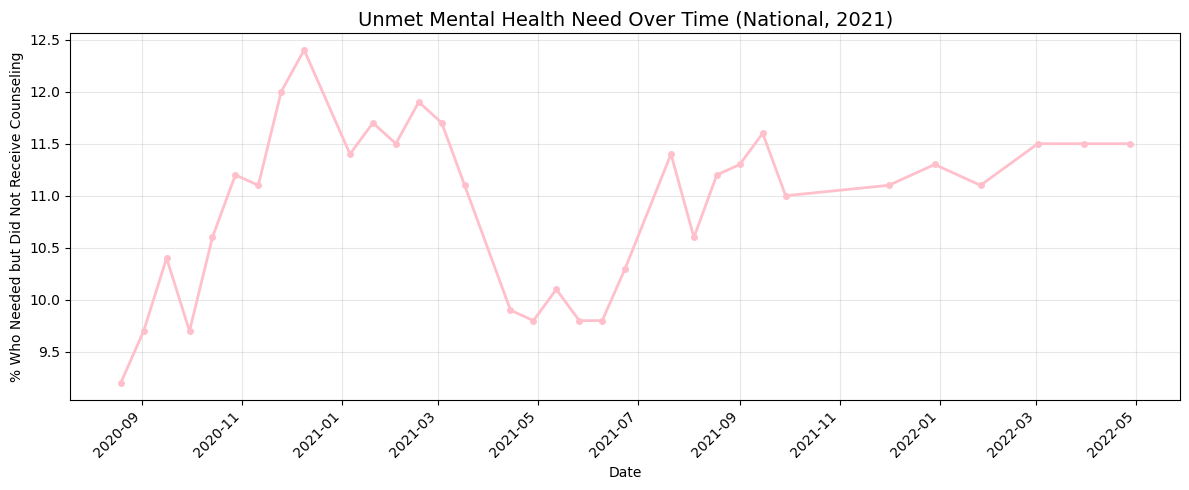

In [12]:
import matplotlib.pyplot as plt

national_needed = needed[needed['Group'] == 'National Estimate']

plt.figure(figsize=(12, 5))
plt.plot(national_needed['Time Period Start Date'], 
         national_needed['Value'], 
         color='pink', linewidth=2, marker='o', markersize=4)

plt.title('Unmet Mental Health Need Over Time (National, 2021)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('% Who Needed but Did Not Receive Counseling')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding 1: National Unmet Mental Health Need**

This chart shows the percentage of U.S. adults who reported needing counseling or therapy in the past 4 weeks but were unable to access it. 

The unmet needs started relatively low in August 2020 (9.2%) before rising steadily through late 2020, where they peaked at approximately 12.4% in January 2021. This peak coincides with major COVID-29 waves in the U.S., during which mental health need was high, but accessibility was disrupted due to the pandemic. 

There is then a decline around April and June 2021, dropping to around 9.8%. This coincides slightly with the initial vaccination rollout, expanded telehealth access, and gradual reopening on in-person activities. 

Unmet need stabilizes between 11-12% through the remainder of 2021 and into 2022, suggesting that a persistent baseline of unmet mental health need remained after the initial acute crisis onset. This means that roughly 1 in 9 American adults were unable to access care they identified as needed. 

# Care Gap

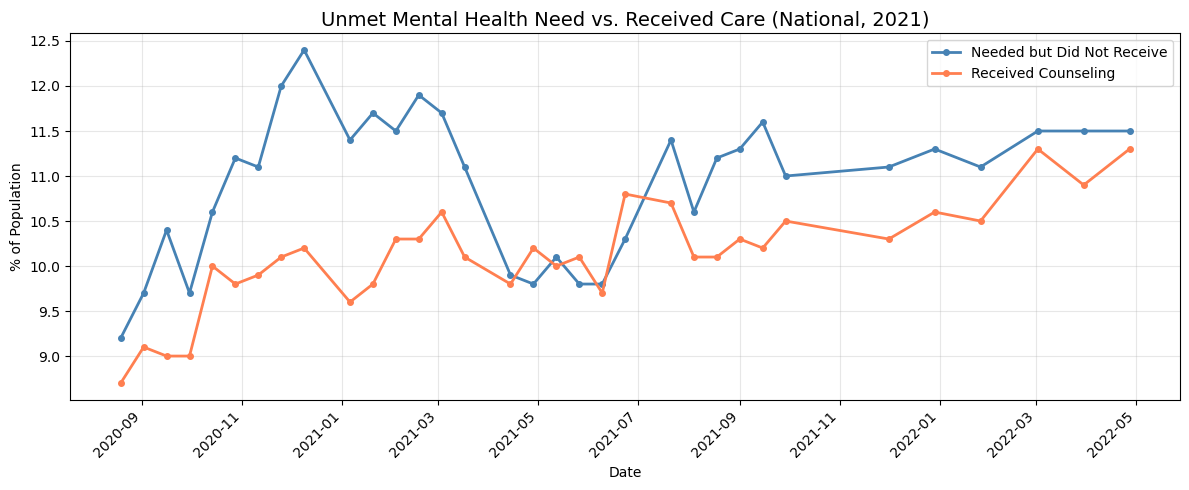

In [13]:
national_received = received[received['Group'] == 'National Estimate']

plt.figure(figsize=(12, 5))
plt.plot(national_needed['Time Period Start Date'], 
         national_needed['Value'],
         color='steelblue', linewidth=2, marker='o', markersize=4, label='Needed but Did Not Receive')
plt.plot(national_received['Time Period Start Date'], 
         national_received['Value'],
         color='coral', linewidth=2, marker='o', markersize=4, label='Received Counseling')

plt.title('Unmet Mental Health Need vs. Received Care (National, 2021)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('% of Population')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding 2: National Unmet Need VS. Received Care**

This chart compares the percentage of U.S. adults who needed counseling or therapy in the past 4 weeks against those who received it, tracked from August 2020 through April 2022. 

Throughout a majority of the period, the unmet need exceeds those who received care. There were consistently people who reported needing mental health counseling than those who were able to access it. The gap was widest in early 2021, when unmet need peaked around 12.4% while the care received was about 9.6%

The two lines came closest during July of 2021, suggesting a moment where expanded telehealth access and vaccine rollout helped close the gap. After July of 2021, the gap widens again through 2022.

The rate of care received trends upwards across the whole period, suggesting that more people were able to access care overtime. Unmet need remained elevated, suggesting that the demand for mental health services grew faster than the system’s capacity to meet it.


In [14]:
# Merge needed and received on date and subgroup
gap_df = national_needed[['Time Period Start Date', 'Value']].copy()
gap_df = gap_df.rename(columns={'Value': 'Needed'})

received_vals = national_received[['Time Period Start Date', 'Value']].copy()
received_vals = received_vals.rename(columns={'Value': 'Received'})

gap_df = gap_df.merge(received_vals, on='Time Period Start Date')
gap_df['Gap'] = gap_df['Needed'] - gap_df['Received']

print(gap_df[['Time Period Start Date', 'Needed', 'Received', 'Gap']].round(1))
print(f"Average gap: {round(gap_df['Gap'].mean(), 1)} percentage points")
print(f"Largest gap: {round(gap_df['Gap'].max(), 1)} percentage points")
print(f"Smallest gap: {round(gap_df['Gap'].min(), 1)} percentage points")

   Time Period Start Date  Needed  Received  Gap
0              2020-08-19     9.2       8.7  0.5
1              2020-09-02     9.7       9.1  0.6
2              2020-09-16    10.4       9.0  1.4
3              2020-09-30     9.7       9.0  0.7
4              2020-10-14    10.6      10.0  0.6
5              2020-10-28    11.2       9.8  1.4
6              2020-11-11    11.1       9.9  1.2
7              2020-11-25    12.0      10.1  1.9
8              2020-12-09    12.4      10.2  2.2
9              2021-01-06    11.4       9.6  1.8
10             2021-01-20    11.7       9.8  1.9
11             2021-02-03    11.5      10.3  1.2
12             2021-02-17    11.9      10.3  1.6
13             2021-03-03    11.7      10.6  1.1
14             2021-03-17    11.1      10.1  1.0
15             2021-04-14     9.9       9.8  0.1
16             2021-04-28     9.8      10.2 -0.4
17             2021-05-12    10.1      10.0  0.1
18             2021-05-26     9.8      10.1 -0.3
19             2021-

In [15]:
print(f"Average gap: {round(gap_df['Gap'].mean(), 1)} percentage points")
print(f"Largest gap: {round(gap_df['Gap'].max(), 1)} percentage points")
print(f"Smallest gap: {round(gap_df['Gap'].min(), 1)} percentage points")

Average gap: 0.8 percentage points
Largest gap: 2.2 percentage points
Smallest gap: -0.5 percentage points


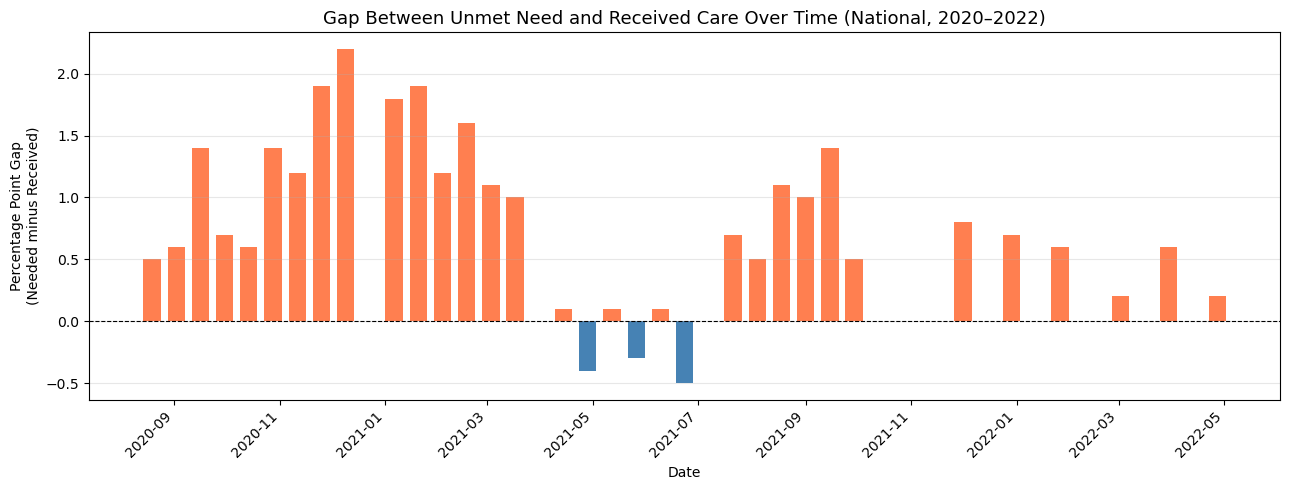

In [16]:
plt.figure(figsize=(13, 5))
colors = ['coral' if x >= 0 else 'steelblue' for x in gap_df['Gap']]

plt.bar(gap_df['Time Period Start Date'], gap_df['Gap'], 
        color=colors, width=10)

plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Gap Between Unmet Need and Received Care Over Time (National, 2020–2022)', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Percentage Point Gap\n(Needed minus Received)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Finding 3: Quantifying the Gap Between Unmet Need and Received Care**

While Finding 2 visualized the relationship between unmet need and received care, this chart quantifies the precise gap between them over time, showing where the mental health system briefly caught up with, or exceeded, reported need.

The average gap between unmet need and received care was 0.8 points, suggesting that there was only an average difference between needing care and receiving care of less than 1% nationally. This highlights the need to look deeper into unmet need by demographic groups, as there may be larger gaps there. While the national gap appears small, this masks substantial disparities across demographic groups, which are explored in the following sections.

The largest gap between unmet need and received care peaks in December of 2020, at 2.2 points. This is likely due to a peak in COVID-19, where access to healthcare services was limited. More people were likely to need mental health care due to the impact of the pandemic and isolation.  

There were negative gap values in April, May, and June of 2021, showing that received care exceeded unmet need. This likely reflects the telehealth boom and vaccine rollout driving a surge in people accessing care. 

The return to positive gap values after July 2017 suggests the surge in care access was temporary rather than systemic. When telehealth stabilized and pandemic relief slowed down, unmet need began to surpass received care through the remainder of the study period.


# Care Gap by Age Group

In [17]:
age_needed = needed[
    (needed['Group'] == 'By Age') & 
    (needed['State'] == 'United States')
].copy()

age_groups = age_needed['Subgroup'].unique()
print(age_groups)

['18 - 29 years' '30 - 39 years' '40 - 49 years' '50 - 59 years'
 '60 - 69 years' '70 - 79 years' '80 years and above']


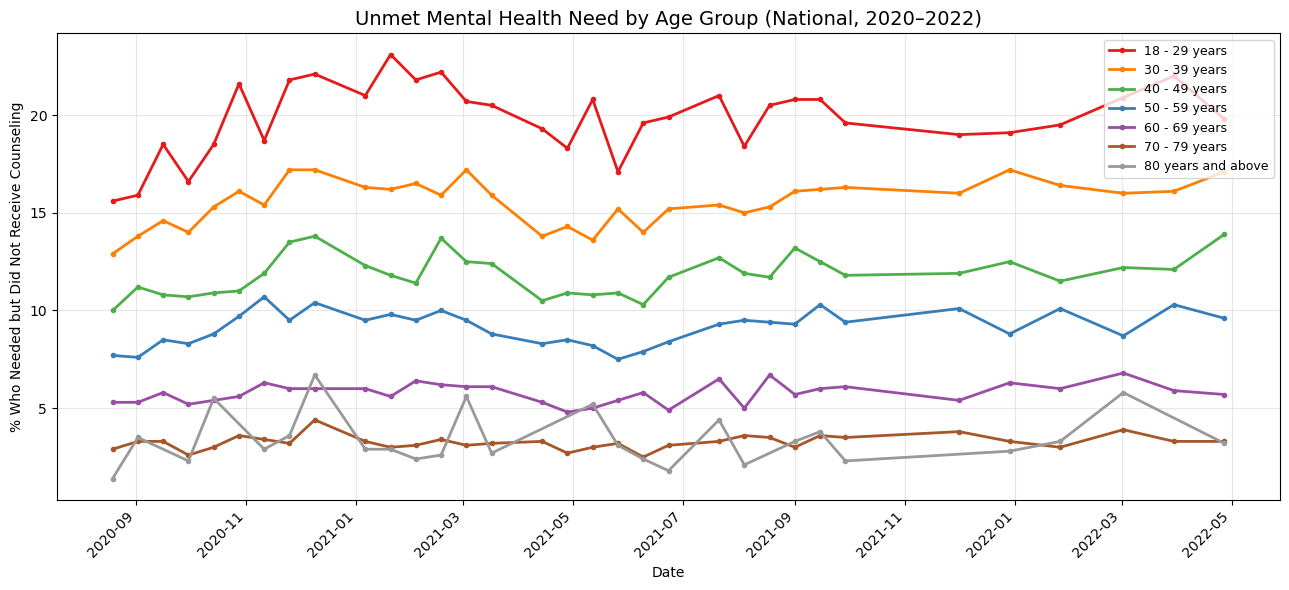

Subgroup
18 - 29 years         19.8
30 - 39 years         15.6
40 - 49 years         11.8
50 - 59 years          9.1
60 - 69 years          5.8
80 years and above     3.4
70 - 79 years          3.3
Name: Value, dtype: float64


In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 6))

colors = ['#e41a1c', '#ff7f00', '#4daf4a', '#377eb8', '#984ea3', '#a65628', '#999999']

for i, group in enumerate(age_groups):
    subset = age_needed[age_needed['Subgroup'] == group]
    subset = subset.sort_values('Time Period Start Date')
    ax.plot(subset['Time Period Start Date'], subset['Value'],
            label=group, color=colors[i], linewidth=2, marker='o', markersize=3)

ax.set_title('Unmet Mental Health Need by Age Group (National, 2020–2022)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('% Who Needed but Did Not Receive Counseling')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(age_needed.groupby('Subgroup')['Value'].mean().sort_values(ascending=False).round(1))

**Finding 4: Unmet Mental Health Need by Age Group**

This chart compares the percentage of U.S. adults who needed counseling or therapy but could not access it, broken down by age group from August 2020 through April 2022.

Adults aged 18-29 years consistently reported the highest unmet need across the whole period, averaging 19.8%. This is more than five times the average unmet need for adults aged 70-79 which comes in at 3.3%. This age range remained stable overtime, with lines crossing infrequently. This may indicate a persistent structural pattern more than a pandemic specific effect. 

This finding is interesting given that young adults are generally more likely to recognize, accept, and seek help for mental health struggles when compared to older adults. This high unmet need may suggest structural barriers, such as limited or no insurance coverage, lower incomes, and fewer provider established relationships. Older adults' lower unmet need may reflect more reliable access through Medicare and long-term provider relationships. It may also reflect the generational differences in willingness to report mental health needs. 



One thing I wanted to consider when analyzing this data by age group, was the sample size of each age group. While the dataset did not provide raw data, I am able to compare confidence intervals as a proxy for sample size reliability. Wider confidence intervals show smaller samples while narrower confidence intervals suggest larger samples. 

In [19]:
age_needed['CI_width'] = age_needed['HighCI'] - age_needed['LowCI']
print(age_needed.groupby('Subgroup')['CI_width'].mean().sort_values(ascending=False).round(2))

Subgroup
18 - 29 years         4.06
80 years and above    3.92
30 - 39 years         2.58
40 - 49 years         2.15
50 - 59 years         1.96
70 - 79 years         1.57
60 - 69 years         1.45
Name: CI_width, dtype: float64


Confidence intervals for the 18–29 and 80+ age groups were notably wider than middle age groups (4.06 and 3.92 percentage points respectively), reflecting smaller or more variable sample sizes for these groups. While the overall age gradient remains robust, estimates for these two groups should be interpreted with slightly more caution.

# Care Gap by Race/Ethnicity

In [20]:
race_needed = needed[
    (needed['Group'] == 'By Race/Hispanic ethnicity') & 
    (needed['State'] == 'United States')
].copy()

print(race_needed['Subgroup'].unique())
print(f"Rows: {len(race_needed)}")

['Hispanic or Latino' 'Non-Hispanic White, single race'
 'Non-Hispanic Black, single race' 'Non-Hispanic Asian, single race'
 'Non-Hispanic, other races and multiple races']
Rows: 165


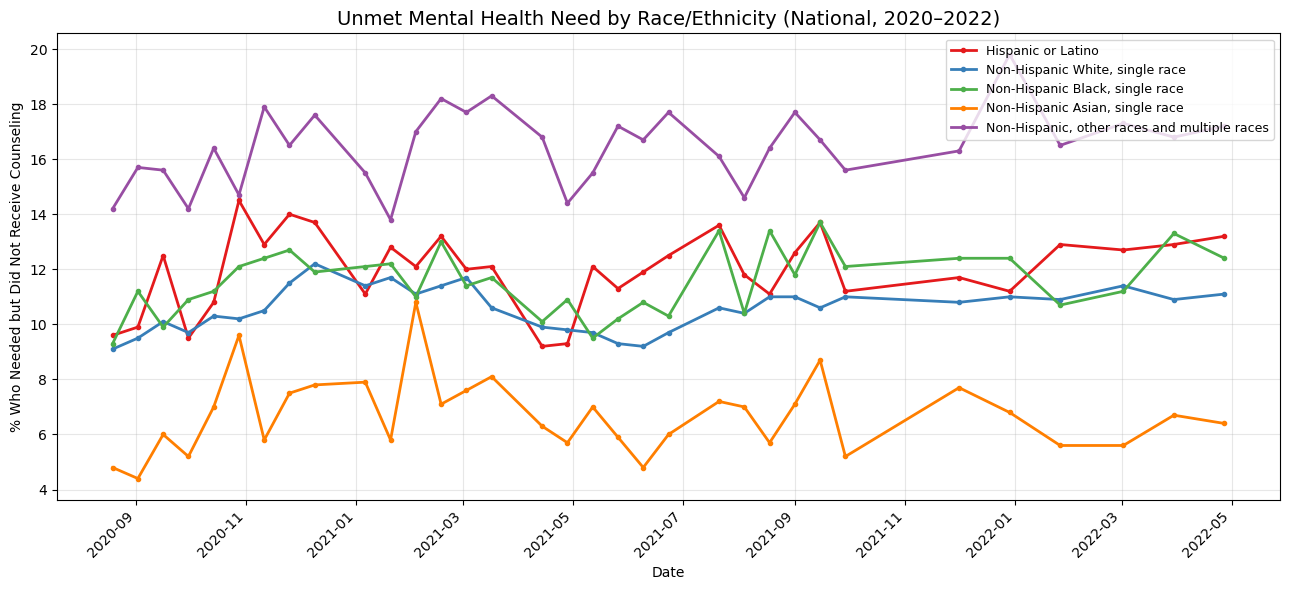

Subgroup
Non-Hispanic, other races and multiple races    16.4
Hispanic or Latino                              12.0
Non-Hispanic Black, single race                 11.6
Non-Hispanic White, single race                 10.6
Non-Hispanic Asian, single race                  6.7
Name: Value, dtype: float64
Subgroup
Non-Hispanic, other races and multiple races    5.85
Non-Hispanic Black, single race                 3.38
Non-Hispanic Asian, single race                 3.34
Hispanic or Latino                              3.31
Non-Hispanic White, single race                 1.05
Name: CI_width, dtype: float64


In [21]:
fig, ax = plt.subplots(figsize=(13, 6))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3']
race_groups = race_needed['Subgroup'].unique()

for i, group in enumerate(race_groups):
    subset = race_needed[race_needed['Subgroup'] == group]
    subset = subset.sort_values('Time Period Start Date')
    ax.plot(subset['Time Period Start Date'], subset['Value'],
            label=group, color=colors[i], linewidth=2, marker='o', markersize=3)

ax.set_title('Unmet Mental Health Need by Race/Ethnicity (National, 2020–2022)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('% Who Needed but Did Not Receive Counseling')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(race_needed.groupby('Subgroup')['Value'].mean().sort_values(ascending=False).round(1))

race_needed['CI_width'] = race_needed['HighCI'] - race_needed['LowCI']
print(race_needed.groupby('Subgroup')['CI_width'].mean().sort_values(ascending=False).round(2))

**Finding 5: Unmet Mental Health Need by Race-Ethnicity**

This chart compares the percentage of U.S. adults who needed counseling or therapy but could not access it, broken down by race/ethnicity group from August 2020 through April 2022.

Non-Hispanic, other race or multiple races consistently report a higher unmet need than other races, with an average of 16.4%. White, black, and Hispanic or Latino all report similar levels of unmet needs, averaging 10.6-12%. Those who are Asian report a significantly lower level of unmet need with an average of 6.6%. 

One thing to consider, Asian Americans are often found to underreport mental health concerns suggesting that their low reported unmet need, may be due to underreporting and not an actual unmet need. 

Note: the non-Hispanic, other races and multiple races estimate carries a confidence interval width of 5.85 percentage points, meaning this finding should be interpreted with caution. The Non-Hispanic White estimate is the most reliable, with a confidence interval width of just 1.05 points.

The similar rates among Hispanic, Black, and White adults suggest that unmet need may be driven by shared structural barriers such as provider availability and cost, rather than race specific factors alone.


# Cross Demographic Comparsion

In [22]:
heatmap_data = needed[
    (needed['State'] == 'United States') &
    (needed['Group'] != 'National Estimate') &
    (needed['Group'] != 'By State')
]

In [23]:
label_map = {
    'Did not experience symptoms of anxiety/depression in the past 4 weeks': 'No anxiety/depression symptoms',
    'Experienced symptoms of anxiety/depression in past 4 weeks': 'Has anxiety/depression symptoms',
    'Non-Hispanic, other races and multiple races': 'Non-Hispanic, other/multiple races',
    "Bachelor's degree or higher": "Bachelor's degree+",
    "Some college/Associate's degree": "Some college/Associate's",
    'Less than a high school diploma': 'Less than high school',
    'High school diploma or GED': 'High school/GED',
    'With disability': 'Has disability',
    'Without disability': 'No disability'
}

heatmap_data = heatmap_data.copy()
heatmap_data['Subgroup'] = heatmap_data['Subgroup'].replace(label_map)

# Pivot using average value per subgroup — collapse time into one number
pivot = heatmap_data.pivot_table(
    index='Subgroup',
    columns='Group',
    values='Value',
    aggfunc='mean'
).round(1)

print(pivot.shape)
print(pivot.columns.tolist())

(28, 8)
['By Age', 'By Disability status', 'By Education', 'By Gender identity', 'By Presence of Symptoms of Anxiety/Depression', 'By Race/Hispanic ethnicity', 'By Sex', 'By Sexual orientation']


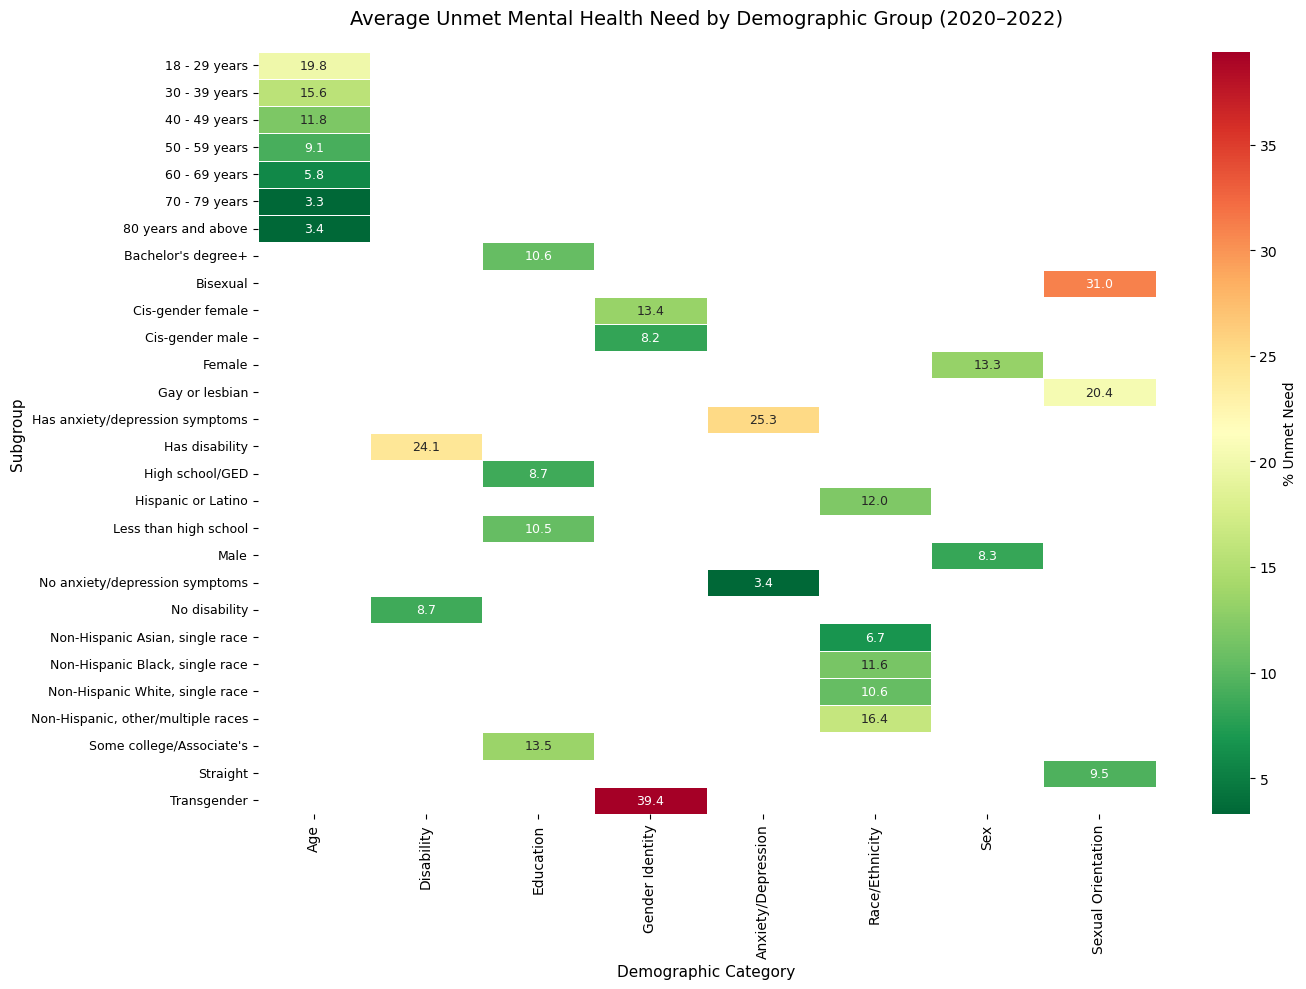

In [24]:
plt.figure(figsize=(14, 10))

# Clean up column names for display
pivot.columns = ['Age', 'Disability', 'Education', 'Gender Identity', 
                 'Anxiety/Depression', 'Race/Ethnicity', 'Sex', 'Sexual Orientation']

sns.heatmap(pivot, 
            annot=True,           # show numbers in cells
            fmt='.1f',            # one decimal place
            cmap='RdYlGn_r',      # red = high unmet need, green = low
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': '% Unmet Need'},
            annot_kws={'size': 9})

plt.title('Average Unmet Mental Health Need by Demographic Group (2020–2022)', 
          fontsize=14, pad=20)
plt.xlabel('Demographic Category', fontsize=11)
plt.ylabel('Subgroup', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()

**Finding 6: Average Unmet Mental Health Need by Demographic Group**

This chart is a cross-demographic comparison of the percentage of unmet need. Unlike previous charts which examined single demographic categories over time, this heatmap provides a comprehensive snapshot across all demographic groups simultaneously, revealing which populations face the most severe barriers to mental health care access.

Transgender Americans report the highest unmet need at 39.4%. This is by far the highest unmet need of any demographic group. Bisexual Americans have the second highest unmet need at 31%, followed by those with anxiety/depression at 25.3% and those who have a disability at 24.1%. Those with no anxiety/depression average an unmet need of 3.4%, which is the lowest of any group. 

Transgender and bisexual Americans' dramatically elevated unmet need may reflect a fear of discrimination, lack of culturally competent providers, or fear of judgment in a healthcare setting. 

Notably, the four highest need groups, all share experiences of compounding stigma or marginalization. This pattern suggests that unmet mental health needs are not randomly distributed across the population, rather it is concentrated among groups who face the greatest barriers to care. Addressing unmet need at a population level may require more targeted interventions for these specific communities.



## Regression Analysis

While earlier sections explored trends and disparities descriptively, a regression model was used to quantify the relationship between demographic factors and unmet mental health needs. 

The goal of this model is explanatory rather than predictive, focusing on how different groups are associated with variations in the gap between needing and receiving mental health care.

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Use the needed dataframe, filter out National Estimate and By State
reg_data = needed[
    (needed['State'] == 'United States') &
    (needed['Group'] != 'National Estimate') &
    (needed['Group'] != 'By State')
].copy()

print(reg_data.shape)
print(reg_data['Group'].unique())

(761, 15)
['By Age' 'By Sex' 'By Presence of Symptoms of Anxiety/Depression'
 'By Race/Hispanic ethnicity' 'By Education' 'By Disability status'
 'By Gender identity' 'By Sexual orientation']


The dependent variable in this model is the percentage of individuals reporting unmet mental health needs. Independent variables include demographic group indicators covering age, sex, race/ethnicity, education level, disability status, gender identity, sexual orientation, and presence of anxiety/depression symptoms.

Categorical variables were encoded using one-hot encoding, with one category serving as the reference group.

In [26]:
# Create dummy variables for Group and Subgroup
reg_encoded = pd.get_dummies(reg_data[['Group', 'Subgroup', 'Value']], 
                              columns=['Group', 'Subgroup'],
                              drop_first=True)

# Separate features and target
X = reg_encoded.drop('Value', axis=1)
y = reg_encoded['Value']

print(f"Features: {X.shape[1]}")
print(f"Observations: {X.shape[0]}")

Features: 34
Observations: 761


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Split data into training and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R-squared: 0.961
RMSE: 1.390


In [28]:
# Check training set R-squared vs test set
train_r2 = r2_score(y_train, model.predict(X_train))
print(f"Training R-squared: {train_r2:.3f}")
print(f"Test R-squared: {r2:.3f}")

Training R-squared: 0.961
Test R-squared: 0.961


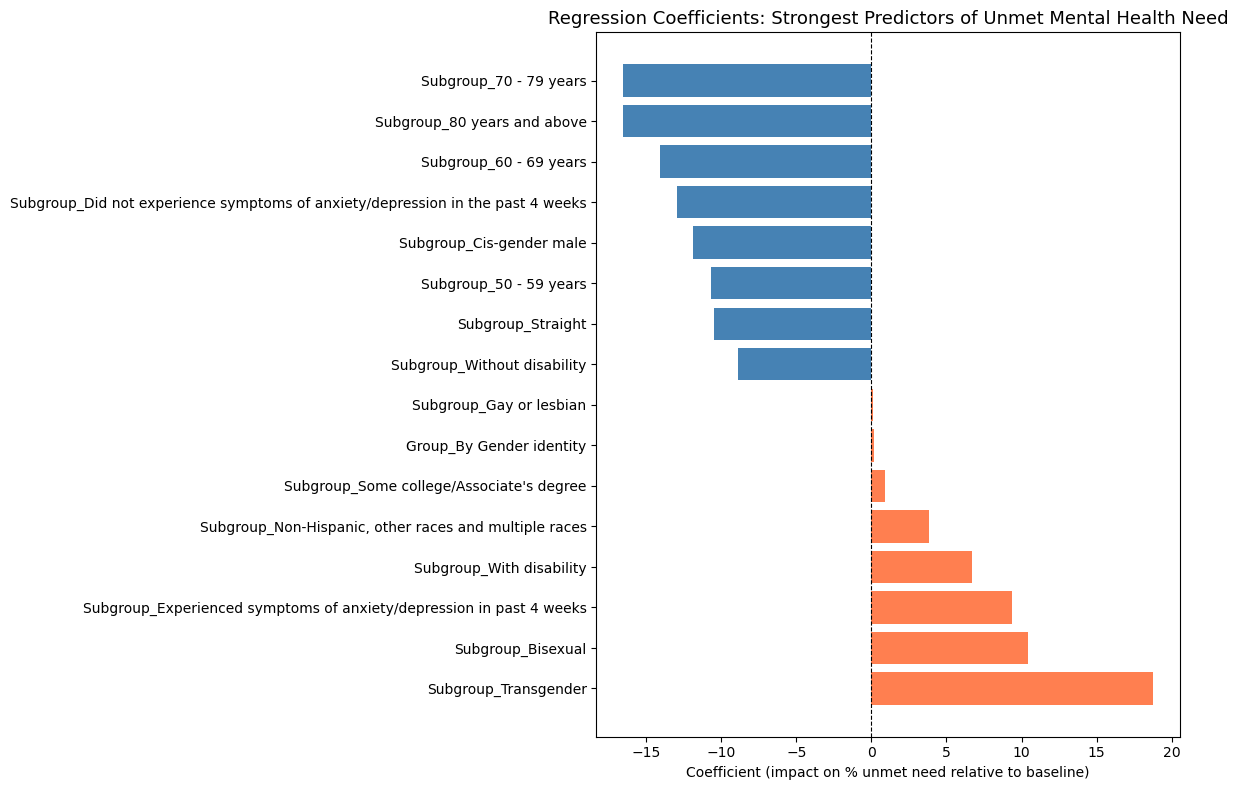

In [29]:
# Get feature importance
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

# Plot top 15 most impactful features
top_features = pd.concat([
    coefficients.head(8),   # highest positive coefficients
    coefficients.tail(8)    # highest negative coefficients
])

plt.figure(figsize=(12, 8))
colors = ['coral' if x > 0 else 'steelblue' for x in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Regression Coefficients: Strongest Predictors of Unmet Mental Health Need', 
          fontsize=13)
plt.xlabel('Coefficient (impact on % unmet need relative to baseline)')
plt.tight_layout()
plt.show()

**Finding 7: Regression Analysis — Predicting Unmet Mental Health Need** 
**from Demographic Group Membership**

To build on the descriptive findings above, I ran a linear regression to 
identify which demographic factors are the strongest statistical predictors 
of unmet mental health need. While the earlier charts show patterns visually, 
regression quantifies how much each demographic group contributes to predicted 
unmet need, which adds mathematical weight to the findings.

**Data Preparation:**
I filtered to national-level data excluding National Estimate and By State 
rows, leaving 761 observations. Since regression requires numerical inputs, 
I converted the categorical Group and Subgroup columns into dummy variables 
(0s and 1s) using one-hot encoding. I used drop_first=True to drop one 
category per group and avoid multicollinearity.

**Model Building:**
I split the data 80/20 into training and test sets so the model could be 
evaluated on data it had never seen, which guards against overfitting.

**Results:**
- R-squared: 0.961 — demographic group membership explains 96.1% of the 
variation in unmet need, suggesting demographics are a very strong predictor
- RMSE: 1.390 — on average, predictions deviate from true values by 1.39 
percentage points
- Training and test R-squared were identical (0.961), confirming no overfitting

**Note on coefficients:**
Each coefficient shows how much higher or lower a group's unmet need is 
compared to the baseline group. Positive = higher unmet need than baseline, 
negative = lower.

**Interpretation**
With an R-squared of 0.961, the model explains 96.1% of variation in unmet need, confirming that demographic group membership is a very strong predictor of unmet mental health needs. 

The three most significant findings come from the subgroups transgender, bisexual, and those who experineced anxiety/depression. The groups had the highest positive coeddicients, showing that being a part of theses subgroups is a strong indicator of having unmet menyal health needs. Transgender Americans having a coefficient of +19 shows a significant chance of experincing unment mental health needs. The model indicates that being a part of these top 3 subgroups is associated with higher unmet mental health needs, reinforcing earlier findings from the descriptive analysis.

The 3 subgroups with the highest negative coefficients were age groups ranging from 60 to 80 and above, with the 2 following being those who did  expeience anxiety or despression in the last 4 weeks, and cisgender males. This suggests that being a part of these subgroups is a strong indicator of NOT having unmet mental health needs. One thing to consider, these subgroups who had high negative coefficients are also often groups who may underreport their need for mental health services. Importantly, these coefficients show correlation between demographic group membership and unmet need, but cannot explain the underlying causes — structural, financial, or cultural barriers require further investigation beyond what this dataset provides.

These regression results confirm the patterns identified in Findings 4, 5, and 6, particularly the elevated unmet need among transgender, bisexual, and disabled populations, and add statistical weight to those descriptive observations. These results are consistent with earlier visualizations, which showed that Transgender Americans  experienced the largest gap.

It is important to note that this model is based on aggregated survey data and does not account for individual-level variation or survey weighting. As a result, the findings should be interpreted as associations rather than causal relationships.

## Key Findings Summary

1. **National unmet need peaked in January 2021** — approximately 12.4% of U.S. 
adults needed counseling but could not access it at the height of the second 
COVID-19 wave, before declining in mid-2021 as vaccine rollout expanded 
telehealth access.

2. **Received care consistently lagged behind need** — unmet need exceeded 
received care in 30 out of 33 survey waves, with the largest gap of 2.2 
percentage points occurring in December 2020. In the remaining 3 waves 
(April–June 2021), received care briefly surpassed reported need, likely 
reflecting the peak of vaccine rollout and telehealth expansion.

3. **Younger adults faced the highest unmet need** — adults aged 18–29 averaged 
19.8% unmet need compared to 3.3% for adults aged 70–79, a pattern that remained 
stable across the entire two-year period.

4. **Racial disparities in access were significant** — Non-Hispanic adults of 
other or multiple races reported the highest average unmet need at 16.4%, while 
Non-Hispanic Asian adults reported the lowest at 6.7%, though the latter finding 
likely reflects underreporting due to cultural stigma rather than lower need.

5. **LGBTQ+ and disabled populations were most severely underserved** — 
transgender adults reported the highest unmet need of any group at 39.4%, 
followed by bisexual adults at 31.0% and adults with disabilities at 24.1%.

6. **Unmet need is concentrated among marginalized groups** — across all 
demographic categories, the groups with the highest unmet need share experiences 
of compounding stigma or structural barriers, suggesting targeted interventions 
are needed rather than broad universal approaches.

7. **Demographic group membership is a strong statistical predictor of unmet need** — a linear regression model explained 96.1% of variation in unmet mental health need (R² = 0.961 ), with ___ identity (coefficient: +___) and ___ adults (coefficient: +___) as the strongest positive predictors, and adults aged ___–___ (coefficient: ___) as the strongest negative predictor.


## Limitations

1. **Self-reported data** — all findings are based on survey self-report, 
meaning respondents identified their own unmet need. This introduces the 
possibility of underreporting or overreporting depending on cultural attitudes 
toward mental health, as noted in the Asian American finding.

2. **Sample sizes by demographic group are not provided** — the dataset does 
not include raw sample counts per subgroup, making it impossible to directly 
assess whether some groups are underrepresented. Confidence interval width 
was used as a proxy, revealing that the 18–29 (4.06 CI width) and 80+ (3.92 CI width) 
age groups and the Non-Hispanic other/multiple races group (5.85 CI width) carry 
more uncertainty than other groups.

3. **Date range** — the dataset covers August 2020 through April 2022 only. 
Findings reflect a specific pandemic period and may not represent long-term 
or pre-pandemic mental health access patterns.

4. **Causal claims are interpretive** — this dataset shows correlation over 
time but cannot confirm causation. The mid-2021 dip in unmet need is 
interpreted as reflecting vaccine rollout and telehealth expansion based on 
external sources, but the dataset itself cannot confirm this directly.

5. **Unmet need is self-identified** — the survey asks respondents whether 
they felt they needed care but didn't get it. It cannot capture people who 
needed care but didn't recognize it, particularly relevant for groups with 
cultural stigma around mental health identification.

## What I Would Do Next

1. **State-level analysis** — this analysis focused on national estimates, 
but the dataset includes all 50 states. A natural next step would be 
examining Oregon specifically, comparing it to the national average across 
demographic groups to identify whether unmet need patterns differ at the 
state level.

2. **Combine with external datasets** — pairing this data with insurance 
coverage rates, provider availability, or income data by demographic group 
would help distinguish between different types of structural barriers. 
For example, does unmet need correlate more strongly with lack of insurance 
or with provider shortages in a given area?

3. **Extend the time range** — this dataset ends in April 2022. Analyzing 
data through 2023 and 2024 would show whether the mid-2021 improvement in 
access was sustained or whether unmet need returned to pandemic-era highs 
as telehealth flexibilities were rolled back.

4. **Build an interactive Tableau dashboard** — converting these findings 
into an interactive dashboard would allow users to filter by demographic 
group and time period, making the analysis more accessible to non-technical 
audiences such as public health policymakers or community organizations.

## References

**Data Source:**
1. U.S. Census Bureau & CDC. Household Pulse Survey: Mental Health Care 
in the Last 4 Weeks. National Center for Health Statistics, 2020–2022.
https://catalog.data.gov/dataset/mental-health-care-in-the-last-4-weeks

**Supporting Sources:**

2. McBain, R.K., et al. "Expansion of Telehealth Availability for Mental 
Health Care After State-Level Policy Changes From 2019 to 2022." 
JAMA Network Open, 2023.
https://pmc.ncbi.nlm.nih.gov/articles/PMC10265313/

3. U.S. Department of Health & Human Services. "New HHS Study Shows 
63-Fold Increase in Medicare Telehealth Utilization During the Pandemic." 
CMS, 2021.
https://www.cms.gov/newsroom/press-releases/new-hhs-study-shows-63-fold-increase-medicare-telehealth-utilization-during-pandemic

4. Our World in Data. "COVID-19 Vaccine Rollout, United States." 2021.
https://ourworldindata.org/covid-vaccinations

5. Tse, J.S.Y. "Inclusiveness of the Concept of Mental Disorder and 
Differences in Help-Seeking Between Asian and White Americans." 
Frontiers in Psychology, 2021.
https://www.frontiersin.org/journals/psychology/articles/10.3389/fpsyg.2021.699750/full

6. Meyer, I.H. "Prejudice, Social Stress, and Mental Health in Lesbian, 
Gay, and Bisexual Populations: Conceptual Issues and Research Evidence." 
Psychological Bulletin, 129(5), 674–697, 2003.
https://pmc.ncbi.nlm.nih.gov/articles/PMC2072932/

In [30]:
df_national.to_csv('mental_health_cleaned.csv', index=False)

In [31]:
gap_df.to_csv('mental_health_gap.csv', index=False)